# ⾃由課題

### 説明

本自由課題では、MNISTデータセットを用いて、手書き数字（0〜9）を分類するニューラルネットワークを実装し学習させました。ニューラルネットワークの数学的原理をより深く理解するため、学習の主要部分（順伝播・逆伝播・パラメータ更新など）は自分で実装し、学習処理に関しては既製の機械学習ライブラリに依存しない形を選びました。

私は2025年春学期の時点で先生の「人工知能ための数学」という授業の内容を事前に調べ、先生が執筆された『最短コースでわかる ディープラーニングの数学』を購入して学習しました。数式と実装の対応が非常に分かりやすく、学びが大きかったことから、本学期（2025年秋学期）に先生の授業を受講することを決めました。なお、本自由課題の内容は、先生のご著書の終盤で扱われているニューラルネットワーク実装の章を土台にしています。

ご著書では重要な部分のコードと解説が示されていますが、私は完成版のコードをそのまま入手するのではなく、解説と自分の理解をもとに実装に挑戦する方針を取りました。試行錯誤を重ね、必要に応じてChatGPTも補助的に活用しながら、最終的に本Notebookの実装を完成させました。

もし改善すべき点や、より適切な実装方法がありましたら、ご指摘いただけますと幸いです。

---

# コード

### データセットの読み込み


In [10]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

# MNIST を読み込み（初回は自動でダウンロード）
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("学習データ：", X_train.shape, y_train.shape)
print("テストデータ：", X_test.shape, y_test.shape)

学習データ： (60000, 28, 28) (60000,)
テストデータ： (10000, 28, 28) (10000,)


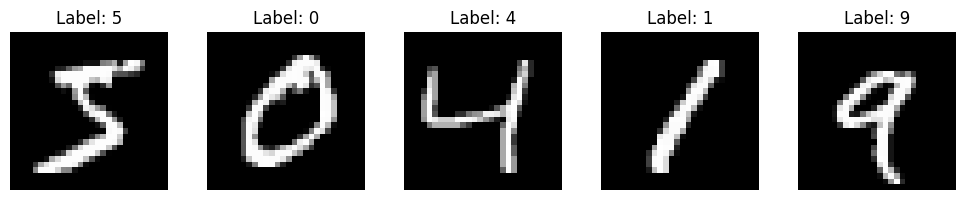

In [11]:
fig, axes = plt.subplots(1, 5, figsize=(10, 2))

for e in range(5):
    axes[e].imshow(X_train[e], cmap='gray')
    axes[e].set_title(f"Label: {y_train[e]}")
    axes[e].axis('off')

plt.tight_layout()
plt.show()

### データの前処理


In [12]:
from sklearn.preprocessing import OneHotEncoder

# 形状を変換し、[0, 1] に正規化
X_train = X_train.reshape(-1, 28 * 28) / 255
X_test = X_test.reshape(-1, 28 * 28) / 255

# ラベルを one-hot 表現に変換
oht_encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
y_train = oht_encoder.fit_transform(y_train.reshape(-1, 1))
y_test = oht_encoder.transform(y_test.reshape(-1, 1))

print(y_train[:5])
print(y_test[:5])

[[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]]
[[0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]]


### 関数の実装


In [13]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def softmax(x):
    x_max = np.max(x, axis=1, keepdims=True)
    x = np.exp(x - x_max)
    x_sums = np.sum(x, axis=1, keepdims=True)
    return x / x_sums

def ReLU(x):
    return np.maximum(0, x)

def step(x):
    return (x > 0).astype(float)

def pred(x, w):
    # w は各層の重み行列（バイアス項を含む）: [W1, W2, ..., W_out]
    # 戻り値: y_pred（確率）, inputs（各層入力）, linear_result（ReLU 前の z）
    # 各層への入力（バイアス項を含む）を保存する
    inputs = [None] * len(w)
    linear_result = [None] * (len(w) - 1)

    # 1層目〜出力層直前までの順伝播
    for i in range(len(w) - 1):
        x = np.hstack((np.ones((x.shape[0], 1)), x))    # 先頭列に 1 を追加（バイアス項）
        inputs[i] = x                                   # 各層の入力を保存
        x = x @ w[i]                                    # 線形変換
        linear_result[i] = x                            # ReLU 前の線形出力 z を保存
        x = ReLU(x)                                     # 活性化関数（ReLU）

    # 出力層の順伝播
    x = np.hstack((np.ones((x.shape[0], 1)), x))    # 先頭列に 1 を追加（バイアス項）
    inputs[-1] = x                                  # 各層の入力を保存
    x = softmax(x @ w[-1])                          # 出力層の順伝播

    return x, inputs, linear_result

# one-hot 表現をクラスラベル（0〜9）に変換
def to_lable(y):
    return np.argmax(y, axis=1)

# 交差エントロピー損失（数値安定化のため clip を使用）
def cross_entropy(y_pred, y_true, eps=1e-12):
    y_pred = np.clip(y_pred, eps, 1.0)
    return -np.mean(np.sum(y_true * np.log(y_pred), axis=1))

# 正解率の計算（one-hot をラベルに変換して比較）
def accuracy_score(y_pred, y_true):
    return np.sum(to_lable(y_pred) == to_lable(y_true)) / y_pred.shape[0]

### ハイパーパラメータの設定


In [14]:
# パラメター設定
epoch = 100                     # エポック数
alpha = 0.01                    # 学習率
batch_size = 512                # ミニバッチサイズ
n_samples = X_train.shape[0]    # 学習データ数（サンプル数）
input_dim  = X_train.shape[1]   # 入力次元（特徴量数）


# 重み行列の初期化（スケール調整）
w = [
    np.random.randn(input_dim + 1, 128) / np.sqrt((input_dim + 1) / 2),
    np.random.randn(129, 128) / np.sqrt(129 / 2),
    np.random.randn(129, y_train.shape[1]) / np.sqrt(129 / 2)
    ]

# 記録
history = np.zeros((0, 3))


### 訓練


In [15]:
for e in range(epoch):
    # 学習データをシャッフル
    indexes = np.random.permutation(n_samples)

    for i in range(0, n_samples, batch_size):
        # ミニバッチを作成
        X_batch = X_train[indexes[i:min(n_samples, i + batch_size)]]
        y_batch = y_train[indexes[i:min(n_samples, i + batch_size)]]

        # 順伝播
        y_pred, inputs, linear_result = pred(X_batch, w)

        # 逆伝播（勾配計算）と重み更新
        y_diff = y_pred - y_batch

        for j in range(len(w) - 1, -1, -1):
            w_old = w[j][1:].T
            w[j] = w[j] - alpha * (inputs[j].T @ y_diff / inputs[j].shape[0])

            if j > 0:
                y_diff = step(linear_result[j - 1]) * (y_diff @ w_old)

    # 各 epoch 終了後に評価（テストデータ）
    if e % 5 == 0:
        y_test_pred, _, _ = pred(X_test, w)
        loss = cross_entropy(y_test_pred, y_test)
        acc = accuracy_score(y_test_pred, y_test)
        history = np.vstack((history, [e, loss, acc]))
        print(f"epoch:{e:>3}, loss:{loss:<20}, accuracy:{acc}")

epoch:  0, loss:1.3548616754707592  , accuracy:0.6983
epoch:  5, loss:0.42056433869366183 , accuracy:0.8879
epoch: 10, loss:0.3308445488974027  , accuracy:0.9061
epoch: 15, loss:0.2912329210884902  , accuracy:0.9176
epoch: 20, loss:0.2657073931124195  , accuracy:0.9238
epoch: 25, loss:0.24773561589916854 , accuracy:0.9303
epoch: 30, loss:0.23286982253149555 , accuracy:0.935
epoch: 35, loss:0.21978883325246074 , accuracy:0.939
epoch: 40, loss:0.20906735564664608 , accuracy:0.9414
epoch: 45, loss:0.19968979943978235 , accuracy:0.9444
epoch: 50, loss:0.19106372506315614 , accuracy:0.9463
epoch: 55, loss:0.1830761768103098  , accuracy:0.9483
epoch: 60, loss:0.17615670386710713 , accuracy:0.9493
epoch: 65, loss:0.17032801793037755 , accuracy:0.9504
epoch: 70, loss:0.16495049749717355 , accuracy:0.951
epoch: 75, loss:0.15947739541601427 , accuracy:0.9526
epoch: 80, loss:0.154512952546859   , accuracy:0.9542
epoch: 85, loss:0.14965274038700357 , accuracy:0.9555
epoch: 90, loss:0.1450708493071

### 可視化


損失曲線


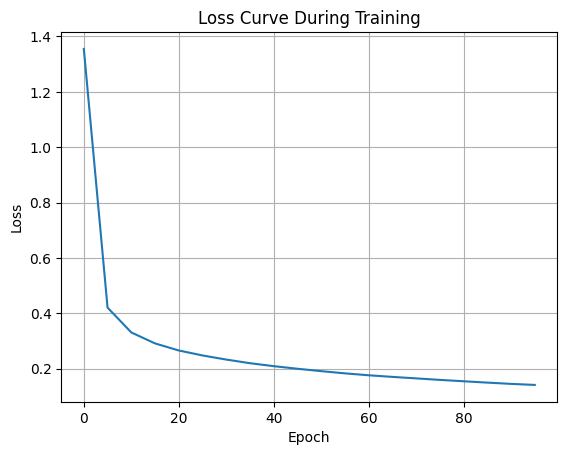

In [16]:
plt.plot(history[:, 0], history[:, 1])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve During Training")
plt.grid(True)
plt.show()

正解率


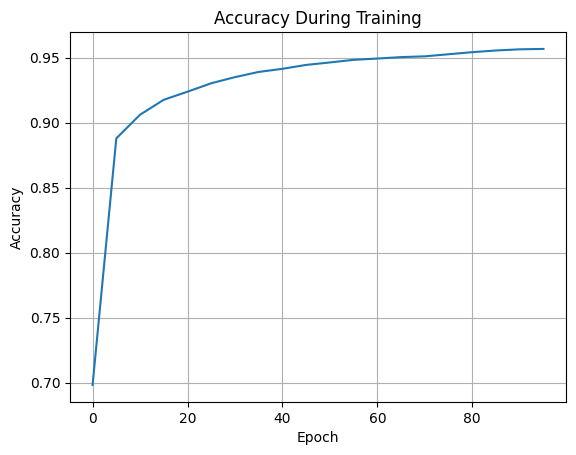

In [17]:
plt.plot(history[:, 0], history[:, 2])
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy During Training")
plt.grid(True)
plt.show()

### 最終評価


In [18]:
y_test_pred, _, _ = pred(X_test, w)
accuracy_score(y_test_pred, y_test)

np.float64(0.958)

---

# まとめ

本NotebookではMNISTデータセットを用いたニューラルネットワークを自作実装し、学習を行いました。学習過程では損失が低下し、精度が上昇していく様子が学習曲線から確認でき、学習が収束していることを確かめられました。最終的に、テストデータに対する正解率は 0.958 となりました。今回の自由課題を通じて、講義で扱った数式（順伝播・逆伝播・損失関数・勾配降下法）が、実際の学習アルゴリズムとしてどのように動くかを自分の手で確認できました。

先生の授業とご著書は、数式と実装のつながりが明確で学びやすく、学習のモチベーションにもつながりました。大変勉強になりました。ご指導ありがとうございました。